# Balanced Random Forest Training (Strictly Timed Features)

This notebook creates a **perfectly 50/50 balanced dataset** consisting of exactly 1,362 meticulously timed Benign flows and 1,362 timed C2 flows, just like the original paper structure. However, because both classes now share the **exact same 120-second timeout extraction methodology**, any detection by the machine learning model is guaranteed to be based on genuine behavioral traits (e.g., packet frequencies, sizes) rather than temporal extraction artifacts.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

plt.style.use('seaborn-v0_8-whitegrid')

In [4]:
TARGET_SAMPLES = 1362

# 1. Load the newly expanded strictly timed Benign features
benign_path = '/home/ioht22/contiki-ng/FYP/pcaps/finalcsv/timed_benign_features_expanded.csv'
df_benign = pd.read_csv(benign_path)

# 2. Load the strictly timed Malicious C2 features
c2_path = '/home/ioht22/contiki-ng/FYP/pcaps/finalcsv/unencrypted_mirai_features.csv'
df_c2 = pd.read_csv(c2_path)

print(f"Original datasets:\n - Benign: {len(df_benign):,} flows\n - C&C:    {len(df_c2):,} flows\n")

# 3. Undersample both specifically to 1,362 to match the original architecture
# Notice we keep ID columns temporarily for grouped splitting
df_benign_sampled = df_benign.sample(n=TARGET_SAMPLES, random_state=42)
df_c2_sampled = df_c2.sample(n=TARGET_SAMPLES, random_state=42)

# Define the common feature columns PLUS identifier columns for grouped splitting
common_cols = [
    'src_ip', 'dst_ip', 'dst_port', 'protocol',  # Identity columns for clustering
    'flow_duration', 'packet_count_fwd', 'packet_count_bwd', 
    'byte_count_fwd', 'byte_count_bwd', 'iat_mean', 'iat_std', 
    'iat_max', 'iat_min', 'packet_size_mean', 'packet_size_std', 
    'packet_size_max', 'packet_size_min', 'flow_periodicity', 
    'directionality_ratio', 'label'
]

# 4. Combine into final dataset
df_balanced = pd.concat([
    df_benign_sampled[common_cols], 
    df_c2_sampled[common_cols]
], ignore_index=True)

print(" Successfully created flawless, timeout-matched balanced dataset!")
print(df_balanced['label'].value_counts())

# Optional: Save the cleanly balanced dataset so you have it as a permanent artifact
output_balanced = '/home/ioht22/contiki-ng/FYP/pcaps/finalcsv/fair_balanced_1362_dataset.csv'
df_balanced.to_csv(output_balanced, index=False)
print(f"\nSaved balanced dataset to: {output_balanced}")

Original datasets:
 - Benign: 1,398 flows
 - C&C:    8,369 flows

 Successfully created flawless, timeout-matched balanced dataset!
label
Benign    1362
C&C       1362
Name: count, dtype: int64

Saved balanced dataset to: /home/ioht22/contiki-ng/FYP/pcaps/finalcsv/fair_balanced_1362_dataset.csv


In [5]:
# Preprocess: Clean anomalous infinite/NaN values produced by division in edge cases
df_balanced = df_balanced.replace([np.inf, -np.inf], np.nan)
df_balanced = df_balanced.fillna(0)

# Create a unique integer group ID mapped from the (src_ip, dst_ip, dst_port, protocol) 4-tuple
df_balanced['session_id'] = df_balanced.groupby(['src_ip', 'dst_ip', 'dst_port', 'protocol']).ngroup()

# Extract target array and group array
y = df_balanced['label'].apply(lambda x: 1 if x in ['C&C', 'Malicious'] else 0)
groups = df_balanced['session_id']

# Remove BOTH the label and the identity columns from training features
drop_cols = ['label', 'session_id', 'src_ip', 'dst_ip', 'dst_port', 'protocol']
X = df_balanced.drop(columns=drop_cols)

print(f"Total isolated device-sessions found: {groups.nunique():,}")

# Deploy GroupShuffleSplit to prevent Session Leakage Data Cross-Contamination
gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set: {X_train.shape[0]:,} continuous flows (No identity leak)")
print(f"Testing set:  {X_test.shape[0]:,} contiguous flows (Scientifically unseen!)")

Total isolated device-sessions found: 1,719
Training set: 2,173 continuous flows (No identity leak)
Testing set:  551 contiguous flows (Scientifically unseen!)


Training Random Forest model on the scientifically clean dataset...

--- MODEL CLASSIFICATION REPORT ---
                precision    recall  f1-score   support

    Benign (0)       0.99      1.00      0.99       280
C&C Botnet (1)       1.00      0.99      0.99       271

      accuracy                           0.99       551
     macro avg       0.99      0.99      0.99       551
  weighted avg       0.99      0.99      0.99       551



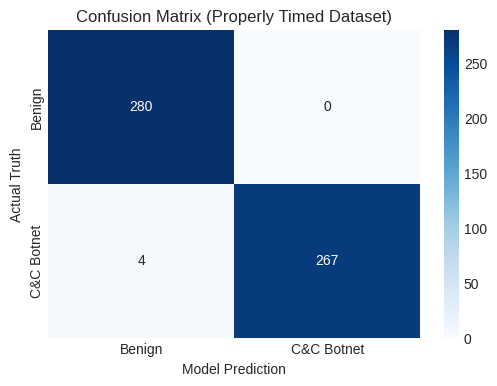

In [6]:
# Train Random Forest Classifier
print("Training Random Forest model on the scientifically clean dataset...")
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_scaled, y_train)

# Evaluate
predictions = rf_model.predict(X_test_scaled)

print("\n--- MODEL CLASSIFICATION REPORT ---")
print(classification_report(y_test, predictions, target_names=['Benign (0)', 'C&C Botnet (1)']))

cm = confusion_matrix(y_test, predictions)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Benign', 'C&C Botnet'], yticklabels=['Benign', 'C&C Botnet'])
plt.title('Confusion Matrix (Properly Timed Dataset)')
plt.ylabel('Actual Truth')
plt.xlabel('Model Prediction')
plt.show()

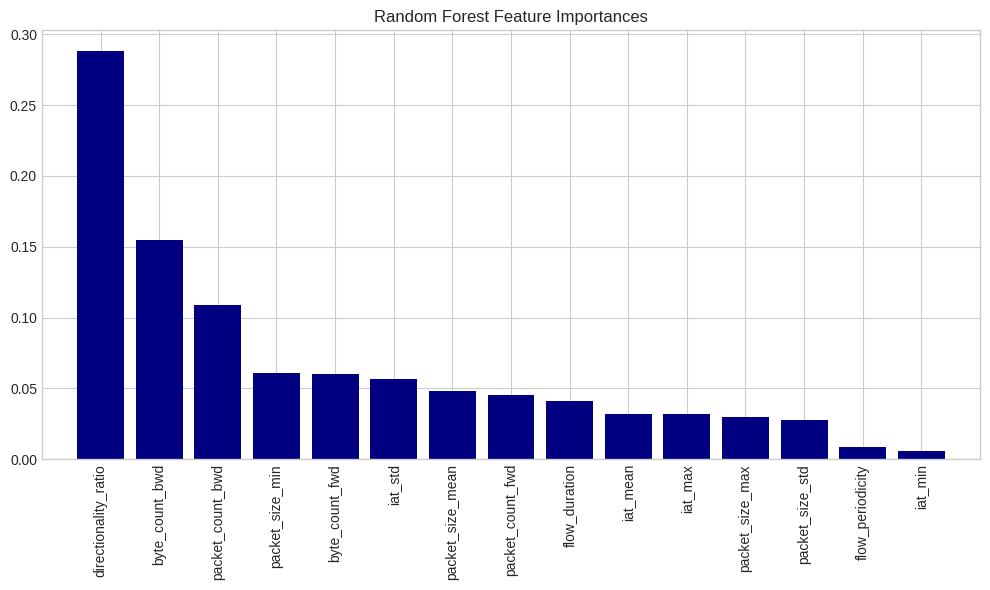

Top 5 Behavioral Indicators Driving Botnet Detection:
1. directionality_ratio (0.2884)
2. byte_count_bwd (0.1547)
3. packet_count_bwd (0.1092)
4. packet_size_min (0.0608)
5. byte_count_fwd (0.0604)


In [8]:
# Feature Importance Analysis
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]
feature_names = X.columns

plt.figure(figsize=(10, 6))
plt.title("Random Forest Feature Importances")
plt.bar(range(X.shape[1]), importances[indices], align="center", color='navy')
plt.xticks(range(X.shape[1]), [feature_names[i] for i in indices], rotation=90)
plt.xlim([-1, X.shape[1]])
plt.tight_layout()
plt.show()

print("Top 5 Behavioral Indicators Driving Botnet Detection:")
for i in range(5):
    print(f"{i+1}. {feature_names[indices[i]]} ({importances[indices[i]]:.4f})")

Loaded 8,159 flows from the Encrypted C2 dataset.

--- PERFORMANCE ON ENCRYPTED C2 ---
                precision    recall  f1-score   support

    Benign (0)       0.00      0.00      0.00         0
C&C Botnet (1)       1.00      0.99      1.00      8159

      accuracy                           0.99      8159
     macro avg       0.50      0.50      0.50      8159
  weighted avg       1.00      0.99      1.00      8159



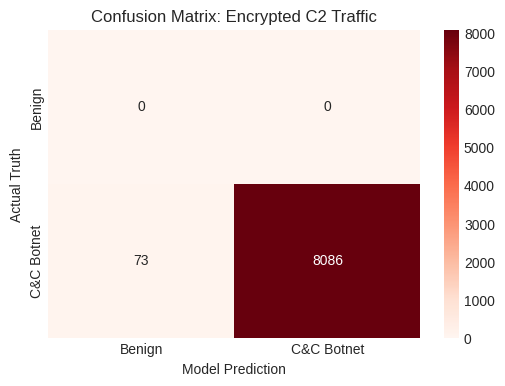

In [10]:
# Test the newly trained model on Encrypted C2 data

encrypted_c2_path = '/home/ioht22/contiki-ng/FYP/pcaps/finalcsv/encrypted_c2_features.csv'
df_enc_c2 = pd.read_csv(encrypted_c2_path)

print(f"Loaded {len(df_enc_c2):,} flows from the Encrypted C2 dataset.")

# Clean up possible NaN/Inf values, as done with the training set
df_enc_c2 = df_enc_c2.replace([np.inf, -np.inf], np.nan).fillna(0)

# Filter columns to only those used by our model
feature_cols = X.columns.tolist()

# Ensure all feature columns exist, fill with 0 if missing
for col in feature_cols:
    if col not in df_enc_c2.columns:
        df_enc_c2[col] = 0

X_enc_c2 = df_enc_c2[feature_cols]

# Apply the same scaling that was fitted on the training set
X_enc_c2_scaled = scaler.transform(X_enc_c2)

# Assuming all traffic in this file is C2 (Label = 1)
y_enc_c2_true = np.ones(len(df_enc_c2))

# Predict
enc_c2_predictions = rf_model.predict(X_enc_c2_scaled)

print("\n--- PERFORMANCE ON ENCRYPTED C2 ---")
print(classification_report(y_enc_c2_true, enc_c2_predictions, labels=[0, 1], target_names=['Benign (0)', 'C&C Botnet (1)'], zero_division=0))

# Visualize the confusion matrix (Note: True label is strictly 1 for this dataset)
cm_enc = confusion_matrix(y_enc_c2_true, enc_c2_predictions, labels=[0, 1])

plt.figure(figsize=(6, 4))
sns.heatmap(cm_enc, annot=True, fmt='d', cmap='Reds', xticklabels=['Benign', 'C&C Botnet'], yticklabels=['Benign', 'C&C Botnet'])
plt.title('Confusion Matrix: Encrypted C2 Traffic')
plt.ylabel('Actual Truth')
plt.xlabel('Model Prediction')
plt.show()

Loaded 2,472 flows from the Encrypted Benign dataset.

--- PERFORMANCE ON ENCRYPTED BENIGN ---
                precision    recall  f1-score   support

    Benign (0)       1.00      0.98      0.99      2472
C&C Botnet (1)       0.00      0.00      0.00         0

      accuracy                           0.98      2472
     macro avg       0.50      0.49      0.50      2472
  weighted avg       1.00      0.98      0.99      2472



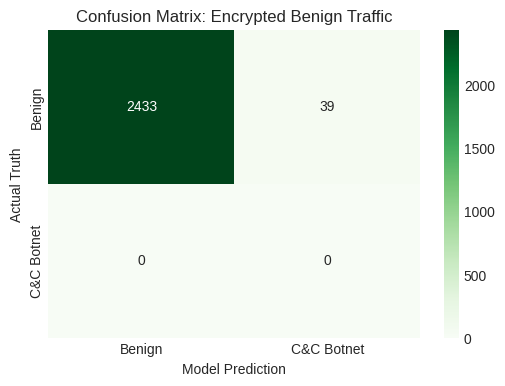

In [11]:
# Test the newly trained model on Encrypted Benign data

encrypted_benign_path = '/home/ioht22/contiki-ng/FYP/pcaps/datasetcsv/encrypted_benign_only.csv'
df_enc_benign = pd.read_csv(encrypted_benign_path)

print(f"Loaded {len(df_enc_benign):,} flows from the Encrypted Benign dataset.")

# Clean up possible NaN/Inf values, as done with the training set
df_enc_benign = df_enc_benign.replace([np.inf, -np.inf], np.nan).fillna(0)

# Ensure all feature columns exist, fill with 0 if missing
for col in feature_cols:
    if col not in df_enc_benign.columns:
        df_enc_benign[col] = 0

X_enc_benign = df_enc_benign[feature_cols]

# Apply the same scaling that was fitted on the training set
X_enc_benign_scaled = scaler.transform(X_enc_benign)

# Assuming all traffic in this file is Benign (Label = 0)
y_enc_benign_true = np.zeros(len(df_enc_benign))

# Predict
enc_benign_predictions = rf_model.predict(X_enc_benign_scaled)

print("\n--- PERFORMANCE ON ENCRYPTED BENIGN ---")
print(classification_report(y_enc_benign_true, enc_benign_predictions, labels=[0, 1], target_names=['Benign (0)', 'C&C Botnet (1)'], zero_division=0))

# Visualize the confusion matrix (Note: True label is strictly 0 for this dataset)
cm_enc_benign = confusion_matrix(y_enc_benign_true, enc_benign_predictions, labels=[0, 1])

plt.figure(figsize=(6, 4))
sns.heatmap(cm_enc_benign, annot=True, fmt='d', cmap='Greens', xticklabels=['Benign', 'C&C Botnet'], yticklabels=['Benign', 'C&C Botnet'])
plt.title('Confusion Matrix: Encrypted Benign Traffic')
plt.ylabel('Actual Truth')
plt.xlabel('Model Prediction')
plt.show()


--- PERFORMANCE ON MIXED ENCRYPTED DATASET ---
Total Samples: 4,944 (Benign Encrypted: 2,472, C2 Encrypted: 2,472)

                precision    recall  f1-score   support

    Benign (0)       0.99      0.98      0.99      2472
C&C Botnet (1)       0.98      0.99      0.99      2472

      accuracy                           0.99      4944
     macro avg       0.99      0.99      0.99      4944
  weighted avg       0.99      0.99      0.99      4944



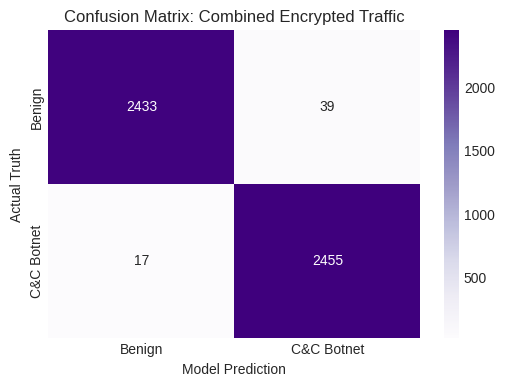

In [12]:
# Test the newly trained model on both Encrypted C2 and Encrypted Benign dataset

# Balance the Encrypted C2 dataset to match the size of Encrypted Benign (2,472 flows)
df_enc_c2_sampled = df_enc_c2.sample(n=len(df_enc_benign), random_state=42)

# Combine both Encrypted C2 and Encrypted Benign datasets for a mixed real-world test
df_mixed_enc = pd.concat([df_enc_benign, df_enc_c2_sampled], ignore_index=True)

# Generate Labels
y_mixed_enc_true = np.concatenate([np.zeros(len(df_enc_benign)), np.ones(len(df_enc_c2_sampled))])

# Extract and scale features
X_mixed_enc = df_mixed_enc[feature_cols]
X_mixed_enc_scaled = scaler.transform(X_mixed_enc)

# Predict
mixed_enc_preds = rf_model.predict(X_mixed_enc_scaled)

print(f"\n--- PERFORMANCE ON MIXED ENCRYPTED DATASET ---")
print(f"Total Samples: {len(df_mixed_enc):,} (Benign Encrypted: {len(df_enc_benign):,}, C2 Encrypted: {len(df_enc_c2_sampled):,})\n")

print(classification_report(y_mixed_enc_true, mixed_enc_preds, target_names=['Benign (0)', 'C&C Botnet (1)']))

# Confusion Matrix
cm_mixed_enc = confusion_matrix(y_mixed_enc_true, mixed_enc_preds)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_mixed_enc, annot=True, fmt='d', cmap='Purples', xticklabels=['Benign', 'C&C Botnet'], yticklabels=['Benign', 'C&C Botnet'])
plt.title('Confusion Matrix: Combined Encrypted Traffic')
plt.ylabel('Actual Truth')
plt.xlabel('Model Prediction')
plt.show()

--- TRAINING TIMING-ORIENTED MODEL ---
Features strictly used: ['flow_duration', 'packet_count_fwd', 'packet_count_bwd', 'iat_mean', 'iat_std', 'iat_max', 'iat_min', 'flow_periodicity', 'directionality_ratio']

--- TIMING MODEL PERFORMANCE (ENCRYPTED BENIGN) ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2472
           1       0.00      0.00      0.00         0

    accuracy                           1.00      2472
   macro avg       0.50      0.50      0.50      2472
weighted avg       1.00      1.00      1.00      2472


--- TIMING MODEL PERFORMANCE (MIXED ENCRYPTED) ---
                precision    recall  f1-score   support

    Benign (0)       0.99      1.00      1.00      2472
C&C Botnet (1)       1.00      0.99      1.00      2472

      accuracy                           1.00      4944
     macro avg       1.00      1.00      1.00      4944
  weighted avg       1.00      1.00      1.00      4944



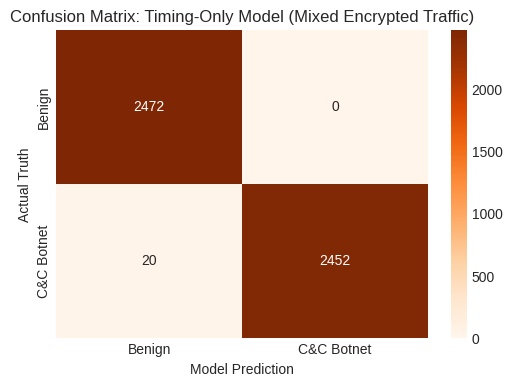

In [13]:
# Rely on Timing and Directionality Instead of Packet Sizes
# Let's train a new model that intentionally ignores packet/byte sizes 
# to prevent TLS padding from tricking the model.

print("--- TRAINING TIMING-ORIENTED MODEL ---")

# 1. Define timing and behavioral features only (dropping packet_size_* and byte_count_*)
timing_features = [
    'flow_duration', 'packet_count_fwd', 'packet_count_bwd', 
    'iat_mean', 'iat_std', 'iat_max', 'iat_min', 
    'flow_periodicity', 'directionality_ratio'
]

print(f"Features strictly used: {timing_features}")

# Get indices of these features from the original X dataframe
timing_indices = [list(X.columns).index(col) for col in timing_features]

# Create new subset feature arrays
X_train_timing = X_train_scaled[:, timing_indices]
X_test_timing = X_test_scaled[:, timing_indices]
X_enc_benign_timing = X_enc_benign_scaled[:, timing_indices]
X_mixed_enc_timing = X_mixed_enc_scaled[:, timing_indices]

# 2. Train the specialized model
rf_timing = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_timing.fit(X_train_timing, y_train)

# 3. Evaluate Encrypted Benign Traffic
timing_enc_benign_preds = rf_timing.predict(X_enc_benign_timing)
print("\n--- TIMING MODEL PERFORMANCE (ENCRYPTED BENIGN) ---")
print(classification_report(y_enc_benign_true, timing_enc_benign_preds, labels=[0, 1], zero_division=0))

# 4. Evaluate Mixed Encrypted Dataset
timing_mixed_preds = rf_timing.predict(X_mixed_enc_timing)
print("\n--- TIMING MODEL PERFORMANCE (MIXED ENCRYPTED) ---")
print(classification_report(y_mixed_enc_true, timing_mixed_preds, target_names=['Benign (0)', 'C&C Botnet (1)'], zero_division=0))

# 5. Visualize Confusion Matrix
cm_timing = confusion_matrix(y_mixed_enc_true, timing_mixed_preds)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_timing, annot=True, fmt='d', cmap='Oranges', xticklabels=['Benign', 'C&C Botnet'], yticklabels=['Benign', 'C&C Botnet'])
plt.title('Confusion Matrix: Timing-Only Model (Mixed Encrypted Traffic)')
plt.ylabel('Actual Truth')
plt.xlabel('Model Prediction')
plt.show()

In [14]:
# Export the newly tuned "Option 2: Timing-Only" Model for live Cooja deployment
import joblib

# 1. Fit a dedicated Scaler ONLY for these timing features to make live inference simple
scaler_timing = StandardScaler()
X_train_timing_raw = X_train[timing_features]  # The unscaled raw extracted dataframe
scaler_timing.fit(X_train_timing_raw)

# 2. Re-train the RF model just to be 100% perfectly synced with this new scaler (identical logic)
rf_timing_final = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
X_train_timing_scaled = scaler_timing.transform(X_train_timing_raw)
rf_timing_final.fit(X_train_timing_scaled, y_train)

# 3. Save Artifacts for the real-time Gateway Detector
joblib.dump(rf_timing_final, '/home/ioht22/contiki-ng/FYP/live_rf_timing_model.joblib')
joblib.dump(scaler_timing, '/home/ioht22/contiki-ng/FYP/live_rf_timing_scaler.joblib')
joblib.dump(timing_features, '/home/ioht22/contiki-ng/FYP/live_rf_timing_features.joblib')

print(" Successfully exported Timing Model, Scaler, and Features for Live Cooja Deployment!")

 Successfully exported Timing Model, Scaler, and Features for Live Cooja Deployment!


## 12. Fair Dataset Paper-Style Evaluation (Ported from dataset_evaluation.ipynb)

This section applies the same evaluation style to the new fair balanced dataset (`fair_balanced_1362_dataset.csv`) without modifying the original dataset evaluation notebook.

In [15]:
# Evaluation setup imports and output directory
import os
import time

from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, precision_recall_curve,
    confusion_matrix, average_precision_score

)
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier

try:
    from xgboost import XGBClassifier
    HAS_XGB_EVAL = True
except Exception:
    HAS_XGB_EVAL = False

FAIR_DATASET_PATH = '/home/ioht22/contiki-ng/FYP/pcaps/finalcsv/fair_balanced_1362_dataset.csv'
FAIR_EVAL_FIG_DIR = '/home/ioht22/contiki-ng/FYP/results/fair_dataset_evaluation'
os.makedirs(FAIR_EVAL_FIG_DIR, exist_ok=True)

print('HAS_XGB_EVAL =', HAS_XGB_EVAL)
print('Evaluation outputs will be saved to:', FAIR_EVAL_FIG_DIR)

HAS_XGB_EVAL = True
Evaluation outputs will be saved to: /home/ioht22/contiki-ng/FYP/results/fair_dataset_evaluation


In [16]:
# Load fair dataset for evaluation
df_eval = pd.read_csv(FAIR_DATASET_PATH)
print(f'Loaded fair dataset: {FAIR_DATASET_PATH}')
print(f'Shape: {df_eval.shape[0]} rows, {df_eval.shape[1]} columns')
print('Label distribution:')
print(df_eval['label'].value_counts(dropna=False))

# Build feature set exactly from available numeric behavior columns
id_cols = ['src_ip', 'dst_ip', 'dst_port', 'protocol', 'label']
FEATURES_EVAL = [c for c in df_eval.columns if c not in id_cols and pd.api.types.is_numeric_dtype(df_eval[c])]

df_eval = df_eval.replace([np.inf, -np.inf], np.nan).fillna(0)
df_eval['label_encoded'] = df_eval['label'].apply(lambda x: 1 if str(x).strip().lower() in ['c&c', 'c2', 'malicious', '1', 'true', 'attack'] else 0)

X_eval_full = df_eval[FEATURES_EVAL].copy()
y_eval_full = df_eval['label_encoded'].astype(int).values

print(f'Behavioral numeric features available: {len(FEATURES_EVAL)}')
print(FEATURES_EVAL)
print(f'Class 0 (Benign): {(y_eval_full == 0).sum()} | Class 1 (C2): {(y_eval_full == 1).sum()}')

Loaded fair dataset: /home/ioht22/contiki-ng/FYP/pcaps/finalcsv/fair_balanced_1362_dataset.csv
Shape: 2724 rows, 20 columns
Label distribution:
label
Benign    1362
C&C       1362
Name: count, dtype: int64
Behavioral numeric features available: 15
['flow_duration', 'packet_count_fwd', 'packet_count_bwd', 'byte_count_fwd', 'byte_count_bwd', 'iat_mean', 'iat_std', 'iat_max', 'iat_min', 'packet_size_mean', 'packet_size_std', 'packet_size_max', 'packet_size_min', 'flow_periodicity', 'directionality_ratio']
Class 0 (Benign): 1362 | Class 1 (C2): 1362


### 12.1 Per-Class Feature Distribution Statistics

In [17]:
benign_eval_df = df_eval[df_eval['label_encoded'] == 0][FEATURES_EVAL]
c2_eval_df = df_eval[df_eval['label_encoded'] == 1][FEATURES_EVAL]

stats_rows = []
for feat in FEATURES_EVAL:
    stats_rows.append({
        'Feature': feat,
        'Benign Mean': benign_eval_df[feat].mean(),
        'Benign Std': benign_eval_df[feat].std(),
        'Benign Median': benign_eval_df[feat].median(),
        'C2 Mean': c2_eval_df[feat].mean(),
        'C2 Std': c2_eval_df[feat].std(),
        'C2 Median': c2_eval_df[feat].median(),
    })

fair_stats_df = pd.DataFrame(stats_rows)
display(fair_stats_df)
fair_stats_df.to_csv(os.path.join(FAIR_EVAL_FIG_DIR, 'fair_per_class_feature_statistics.csv'), index=False)
print('Saved: fair_per_class_feature_statistics.csv')

,Feature,Benign Mean,Benign Std,Benign Median,C2 Mean,C2 Std,C2 Median
0,flow_duration,88.498467,365.139303,2.058829,10.568190,11.657649,7.193781
1,packet_count_fwd,11.335536,98.474252,3.000000,2.651982,4.695194,0.000000
2,packet_count_bwd,10.775330,95.437726,2.000000,5.903084,4.254850,4.000000
3,byte_count_fwd,5772.473568,106559.788827,290.000000,513.116006,5278.823556,0.000000
4,byte_count_bwd,2162.517621,26851.182632,180.000000,446.769457,325.315570,296.000000
5,iat_mean,12.113244,22.661727,0.080983,1.876727,1.100083,2.395591
6,iat_std,4.404762,9.511016,0.060650,2.114696,2.654124,1.259811
7,iat_max,20.851674,29.835678,0.897863,7.634588,10.345361,4.079929
8,iat_min,8.673049,21.969205,0.000389,0.606157,0.511148,1.010299
9,packet_size_mean,136.596962,113.833912,90.000000,82.042694,32.971334,74.000000


Saved: fair_per_class_feature_statistics.csv


### 12.2 Feature Distribution Visualizations

/tmp/ipykernel_815000/365160623.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([data_benign, data_c2], labels=['Benign', 'C2'], patch_artist=True, widths=0.6)
/tmp/ipykernel_815000/365160623.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([data_benign, data_c2], labels=['Benign', 'C2'], patch_artist=True, widths=0.6)
/tmp/ipykernel_815000/365160623.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([data_benign, data_c2], labels=['Benign', 'C2'], patch_artist=True, widths=0.6)
/tmp/ipykernel_815000/365160623.py:12: MatplotlibDeprecationWarning: The 'labels' 

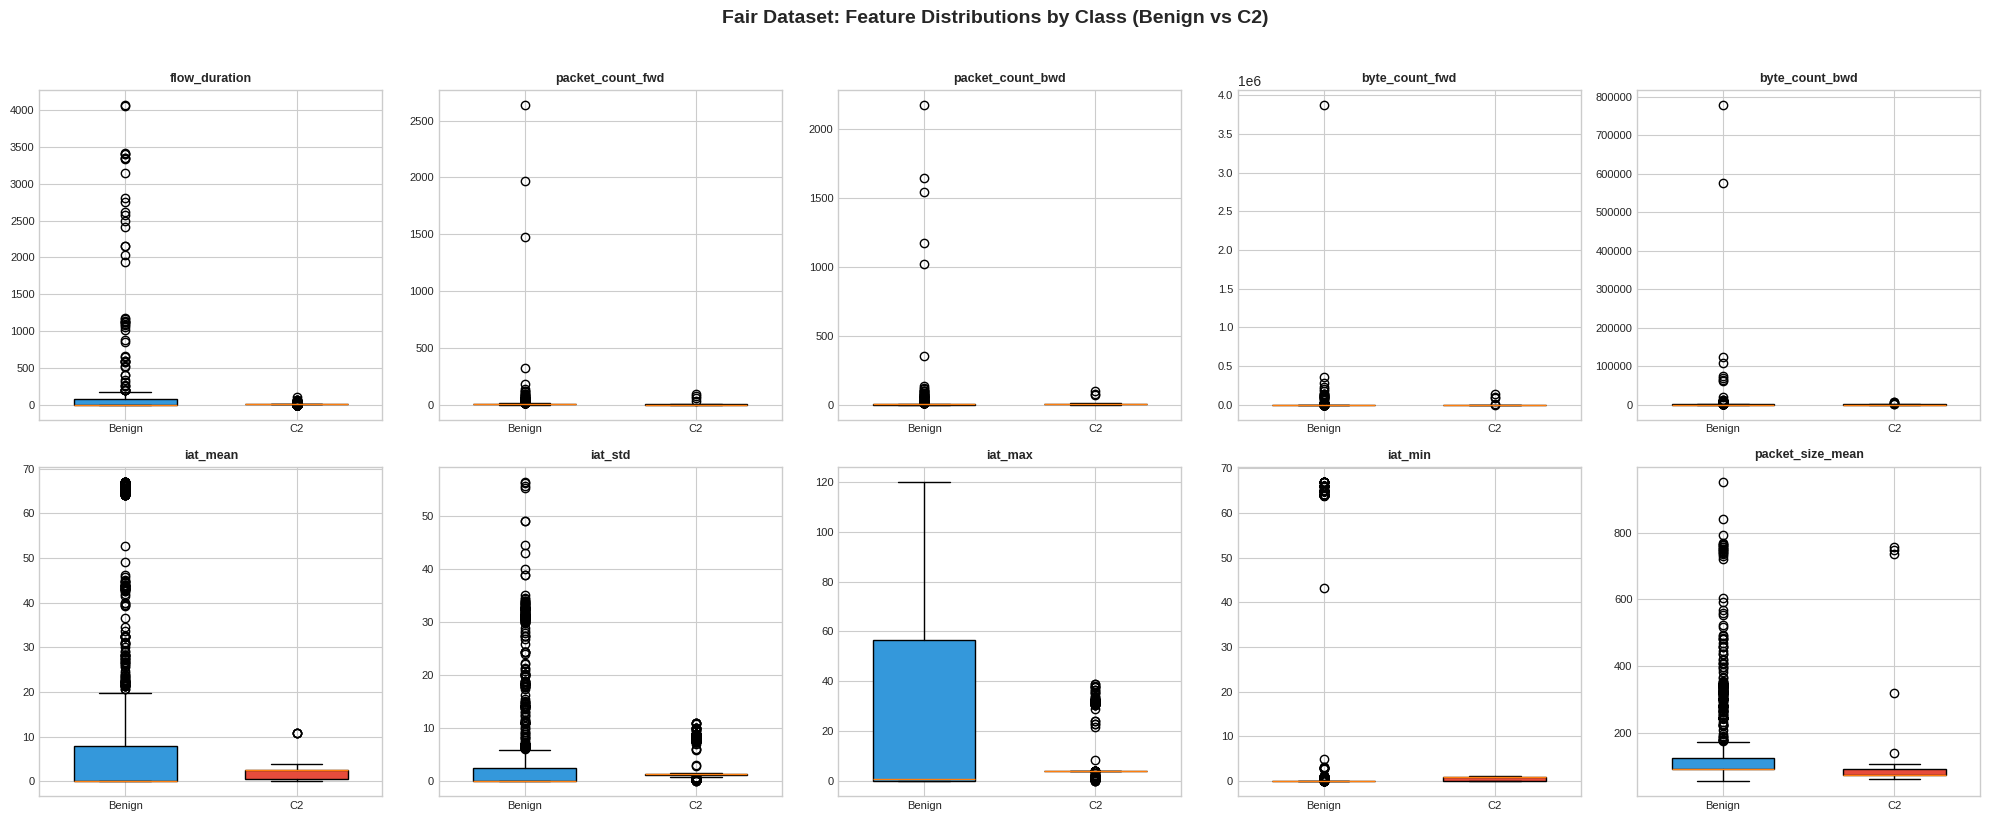

Saved: fair_feature_distributions_boxplot.png


In [14]:
# Box plots for up to 10 features (same style as dataset evaluation notebook)
key_features_eval = FEATURES_EVAL[:10]

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, feat in enumerate(key_features_eval):
    ax = axes[i]
    data_benign = benign_eval_df[feat].dropna()
    data_c2 = c2_eval_df[feat].dropna()

    bp = ax.boxplot([data_benign, data_c2], labels=['Benign', 'C2'], patch_artist=True, widths=0.6)
    bp['boxes'][0].set_facecolor('#3498db')
    bp['boxes'][1].set_facecolor('#e74c3c')
    ax.set_title(feat, fontsize=9, fontweight='bold')
    ax.tick_params(axis='both', labelsize=8)

# Hide unused subplots if less than 10 features
for j in range(len(key_features_eval), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Fair Dataset: Feature Distributions by Class (Benign vs C2)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FAIR_EVAL_FIG_DIR, 'fair_feature_distributions_boxplot.png'), dpi=200, bbox_inches='tight')
plt.show()
print('Saved: fair_feature_distributions_boxplot.png')

### 12.3 Feature Correlation Heatmap

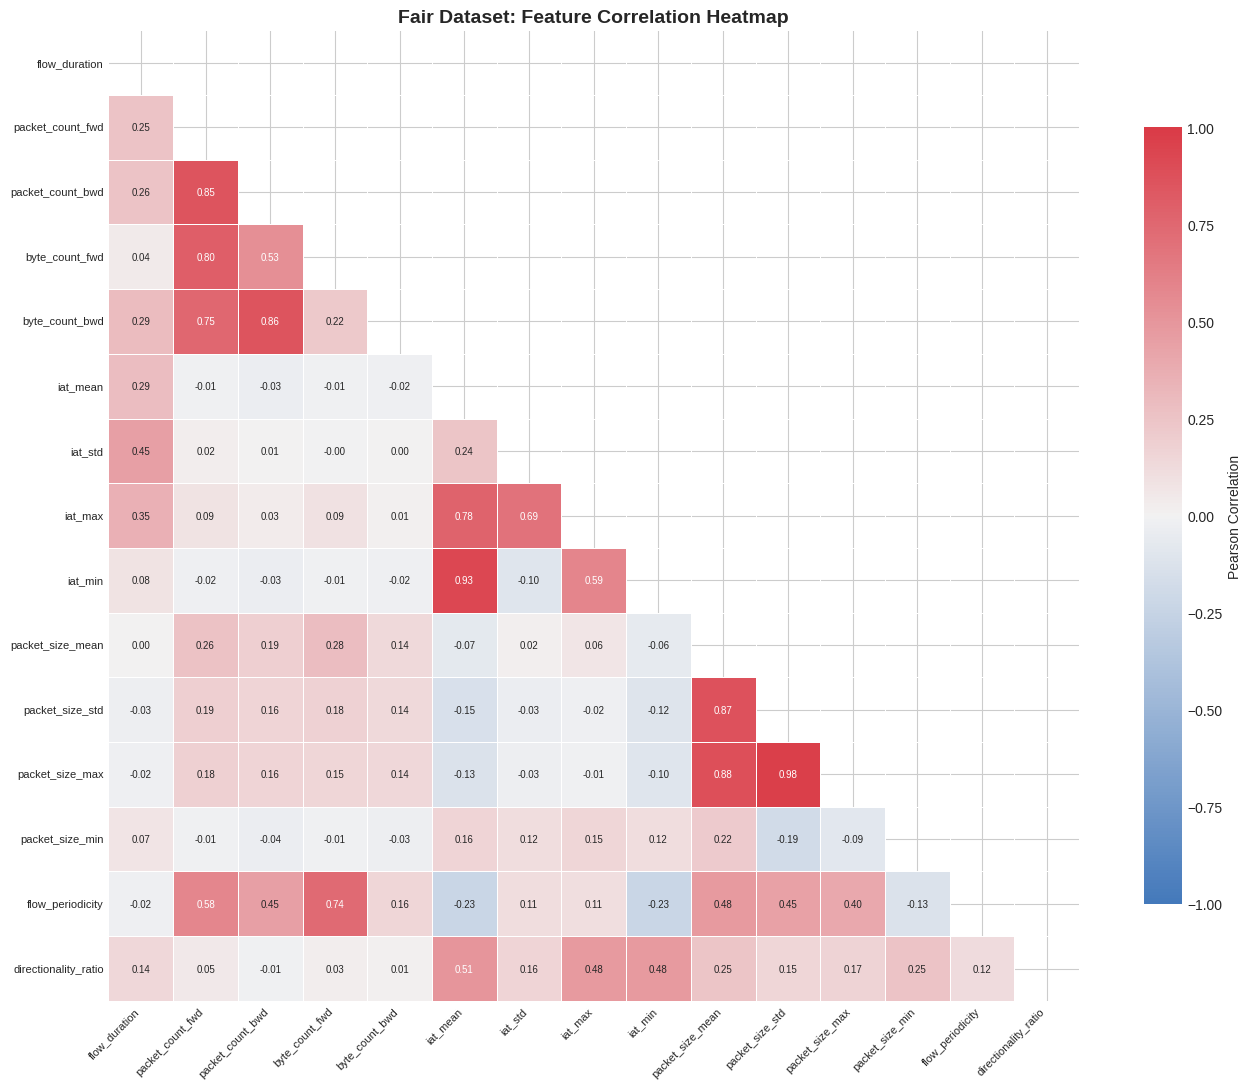

Highly Correlated Feature Pairs (|r| > 0.9):
  iat_mean <-> iat_min: r = 0.9261
  packet_size_std <-> packet_size_max: r = 0.9759
Saved: fair_feature_correlation_heatmap.png


In [15]:
corr_matrix_eval = df_eval[FEATURES_EVAL].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix_eval, dtype=bool))
cmap = sns.diverging_palette(250, 10, as_cmap=True)

sns.heatmap(
    corr_matrix_eval, mask=mask, cmap=cmap, center=0, vmin=-1, vmax=1,
    annot=True, fmt='.2f', square=True, linewidths=0.5, annot_kws={'size': 7},
    cbar_kws={'shrink': 0.8, 'label': 'Pearson Correlation'}, ax=ax
)
ax.set_title('Fair Dataset: Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(FAIR_EVAL_FIG_DIR, 'fair_feature_correlation_heatmap.png'), dpi=200, bbox_inches='tight')
plt.show()

print('Highly Correlated Feature Pairs (|r| > 0.9):')
high_corr_pairs = []
for i in range(len(corr_matrix_eval.columns)):
    for j in range(i + 1, len(corr_matrix_eval.columns)):
        r = corr_matrix_eval.iloc[i, j]
        if abs(r) > 0.9:
            high_corr_pairs.append((corr_matrix_eval.columns[i], corr_matrix_eval.columns[j], r))
            print(f'  {corr_matrix_eval.columns[i]} <-> {corr_matrix_eval.columns[j]}: r = {r:.4f}')
if not high_corr_pairs:
    print('  None found.')

print('Saved: fair_feature_correlation_heatmap.png')

### 12.4 Class Separability Visualization (t-SNE)

Running t-SNE...


t-SNE complete. KL divergence: 0.1960


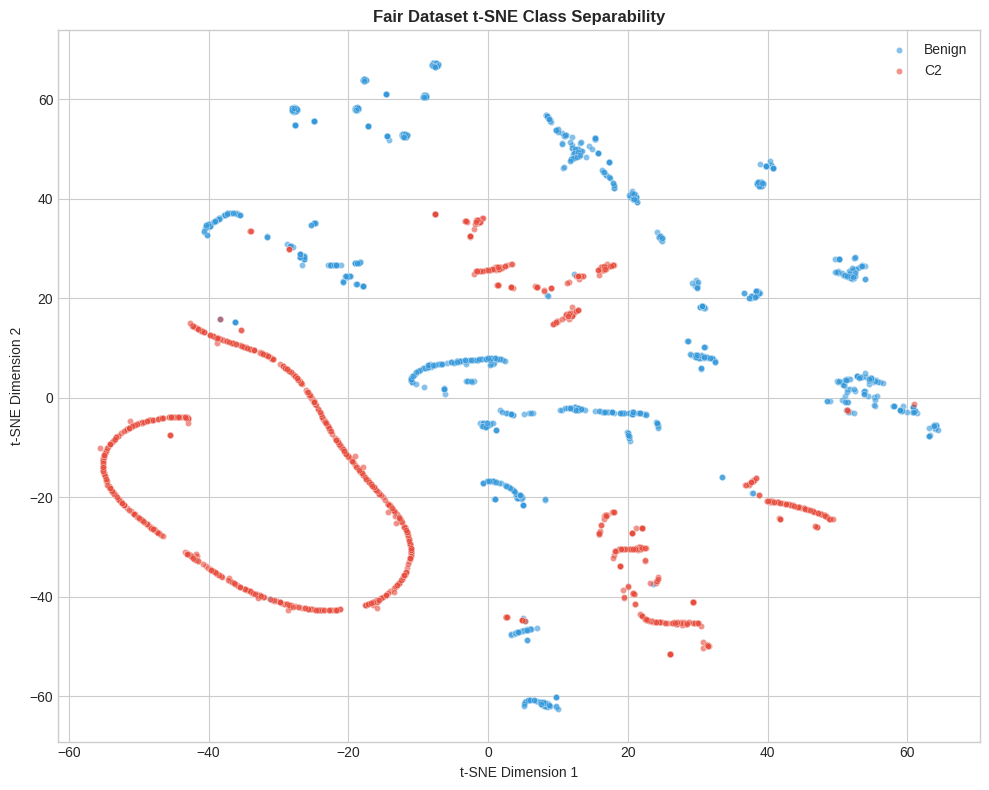

Saved: fair_tsne_class_separability.png


In [16]:
from sklearn.manifold import TSNE

scaler_tsne_eval = StandardScaler()
X_eval_scaled = scaler_tsne_eval.fit_transform(X_eval_full.values)

print('Running t-SNE...')
tsne_eval = TSNE(n_components=2, random_state=42, perplexity=30)
X_eval_tsne = tsne_eval.fit_transform(X_eval_scaled)
print(f't-SNE complete. KL divergence: {tsne_eval.kl_divergence_:.4f}')

fig, ax = plt.subplots(figsize=(10, 8))
for class_idx, color, label_name in [(0, '#3498db', 'Benign'), (1, '#e74c3c', 'C2')]:
    mask = y_eval_full == class_idx
    ax.scatter(
        X_eval_tsne[mask, 0], X_eval_tsne[mask, 1],
        c=color, label=label_name, alpha=0.6, s=20, edgecolors='white', linewidth=0.3
    )
ax.set_xlabel('t-SNE Dimension 1')
ax.set_ylabel('t-SNE Dimension 2')
ax.set_title('Fair Dataset t-SNE Class Separability', fontweight='bold')
ax.legend(loc='best')
plt.tight_layout()
plt.savefig(os.path.join(FAIR_EVAL_FIG_DIR, 'fair_tsne_class_separability.png'), dpi=200, bbox_inches='tight')
plt.show()
print('Saved: fair_tsne_class_separability.png')

### 12.5 K-Fold Cross-Validation (5-fold and 10-fold)

In [17]:
scoring_eval = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

print('=' * 80)
print('K-FOLD CROSS-VALIDATION RESULTS (RANDOM FOREST)')
print('=' * 80)

for k in [5, 10]:
    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)
    rf_cv = RandomForestClassifier(
        n_estimators=200, max_depth=15, min_samples_split=10, min_samples_leaf=5,
        class_weight='balanced', random_state=42, n_jobs=-1
    )
    cv_scores = cross_validate(rf_cv, X_eval_full.values, y_eval_full, cv=skf, scoring=scoring_eval, return_train_score=False)
    print(f'\n{k}-Fold Results:')
    for metric in scoring_eval:
        vals = cv_scores[f'test_{metric}']
        print(f"  {metric:>10s}: {vals.mean():.4f} +/- {vals.std():.4f}")

K-FOLD CROSS-VALIDATION RESULTS (RANDOM FOREST)



5-Fold Results:
    accuracy: 0.9930 +/- 0.0018
   precision: 0.9985 +/- 0.0029
      recall: 0.9875 +/- 0.0029
          f1: 0.9930 +/- 0.0018
     roc_auc: 0.9989 +/- 0.0014



10-Fold Results:
    accuracy: 0.9934 +/- 0.0028
   precision: 0.9985 +/- 0.0030
      recall: 0.9882 +/- 0.0049
          f1: 0.9933 +/- 0.0028
     roc_auc: 0.9986 +/- 0.0020


### 12.6 Multi-Classifier Benchmark + ROC/PR/FPR + McNemar

In [18]:
classifiers_eval = {
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=15, min_samples_split=10, min_samples_leaf=5,
        class_weight='balanced', random_state=42, n_jobs=-1
    ),
    'Decision Tree': DecisionTreeClassifier(max_depth=15, class_weight='balanced', random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, learning_rate=0.08, max_depth=5, random_state=42),
    'SVM (RBF)': SVC(kernel='rbf', probability=True, class_weight='balanced', random_state=42),
    'k-NN (k=5)': KNeighborsClassifier(n_neighbors=5),
    'MLP': MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=500, random_state=42, early_stopping=True),
}
if HAS_XGB_EVAL:
    classifiers_eval['XGBoost'] = XGBClassifier(
        n_estimators=300, max_depth=5, learning_rate=0.08, subsample=0.9, colsample_bytree=0.9,
        eval_metric='logloss', random_state=42, n_jobs=-1
    )

skf5_eval = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
benchmark_results_eval = []

scaler_all_eval = StandardScaler()
X_eval_scaled_all = scaler_all_eval.fit_transform(X_eval_full.values)

print('=' * 90)
print('MULTI-CLASSIFIER BENCHMARK (5-Fold Stratified CV)')
print('=' * 90)

for name, clf in classifiers_eval.items():
    print(f'Training {name}... ', end='')
    X_use = X_eval_scaled_all if name in ['SVM (RBF)', 'k-NN (k=5)', 'MLP'] else X_eval_full.values
    t0 = time.time()
    cv_result = cross_validate(clf, X_use, y_eval_full, cv=skf5_eval, scoring=scoring_eval, return_train_score=False)
    elapsed = time.time() - t0

    row = {'Classifier': name}
    for metric in scoring_eval:
        vals = cv_result[f'test_{metric}']
        row[f'{metric}_mean'] = vals.mean()
        row[f'{metric}_std'] = vals.std()
    row['total_cv_time_s'] = elapsed
    benchmark_results_eval.append(row)
    print(f"done ({elapsed:.2f}s) | Acc={row['accuracy_mean']:.4f} | F1={row['f1_mean']:.4f} | AUC={row['roc_auc_mean']:.4f}")

benchmark_df_eval = pd.DataFrame(benchmark_results_eval)
display(benchmark_df_eval)
benchmark_df_eval.to_csv(os.path.join(FAIR_EVAL_FIG_DIR, 'fair_multi_classifier_benchmark.csv'), index=False)
print('Saved: fair_multi_classifier_benchmark.csv')

MULTI-CLASSIFIER BENCHMARK (5-Fold Stratified CV)
Training Random Forest... 

done (3.39s) | Acc=0.9930 | F1=0.9930 | AUC=0.9989
Training Decision Tree... done (0.11s) | Acc=0.9886 | F1=0.9887 | AUC=0.9904
Training Gradient Boosting... 

done (9.52s) | Acc=0.9923 | F1=0.9923 | AUC=0.9976
Training SVM (RBF)... 

done (0.73s) | Acc=0.9805 | F1=0.9807 | AUC=0.9901
Training k-NN (k=5)... done (0.20s) | Acc=0.9890 | F1=0.9890 | AUC=0.9972
Training MLP... 

done (1.73s) | Acc=0.9842 | F1=0.9843 | AUC=0.9879


,Classifier,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std,total_cv_time_s
0,Random Forest,0.993024,0.001802,0.998529,0.002941,0.987516,0.002949,0.992987,0.001807,0.998886,0.001449,3.385988
1,Decision Tree,0.988620,0.003742,0.986249,0.009278,0.991187,0.004411,0.988671,0.003630,0.990440,0.002145,0.114733
2,Gradient Boosting,0.992290,0.003559,0.993390,0.004270,0.991193,0.002929,0.992289,0.003549,0.997640,0.002553,9.516686
3,SVM (RBF),0.980542,0.004439,0.973967,0.006056,0.987519,0.003746,0.980689,0.004353,0.990089,0.003405,0.725899
4,k-NN (k=5),0.988986,0.003672,0.989032,0.006024,0.988987,0.004027,0.988996,0.003638,0.997178,0.002160,0.195802
5,MLP,0.984214,0.005268,0.980381,0.007334,0.988260,0.004259,0.984295,0.005186,0.987936,0.005323,1.729956


Saved: fair_multi_classifier_benchmark.csv


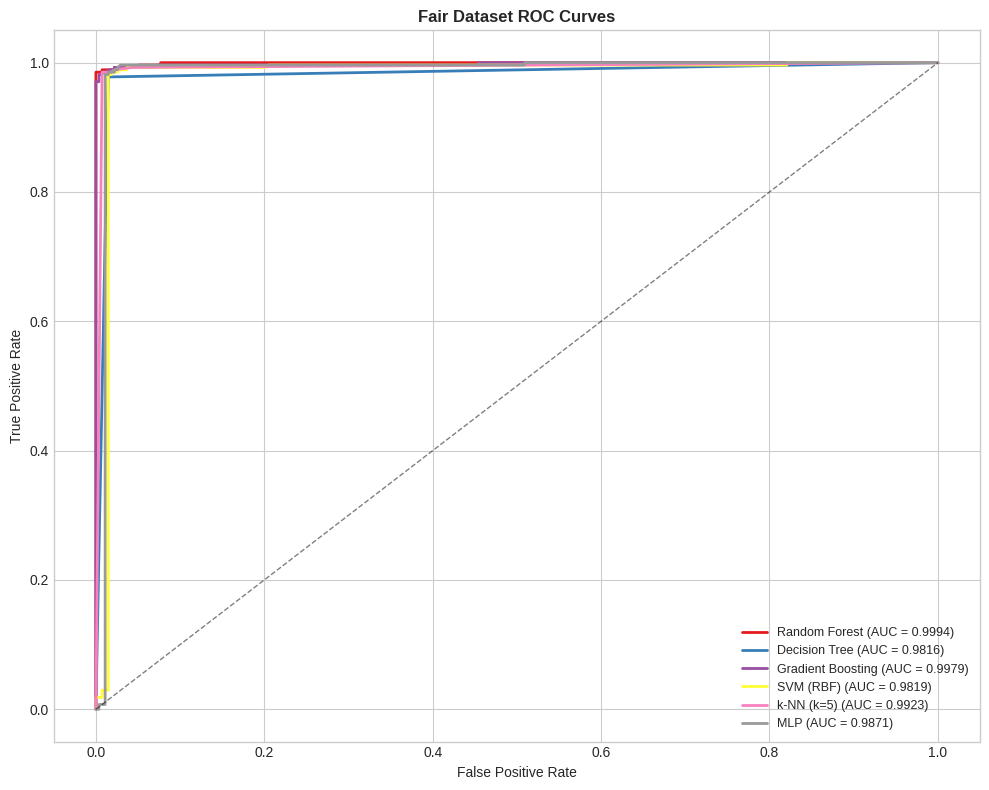

Saved: fair_roc_curves.png


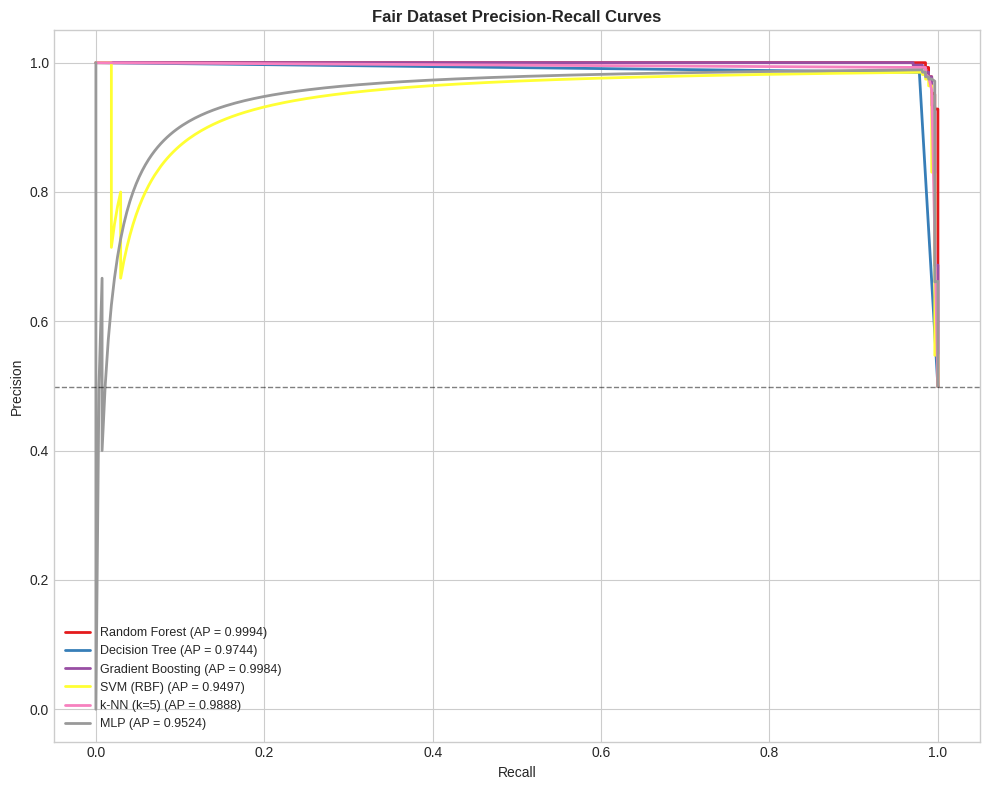

Saved: fair_precision_recall_curves.png


,Classifier,TP,TN,FP,FN,FPR,FNR,Accuracy,Precision,Recall
0,Random Forest,267,273,0,5,0.000000,0.018382,0.990826,1.000000,0.981618
1,Decision Tree,265,269,4,7,0.014652,0.025735,0.979817,0.985130,0.974265
2,Gradient Boosting,269,269,4,3,0.014652,0.011029,0.987156,0.985348,0.988971
5,MLP,267,269,4,5,0.014652,0.018382,0.983486,0.985240,0.981618
4,k-NN (k=5),268,268,5,4,0.018315,0.014706,0.983486,0.981685,0.985294
3,SVM (RBF),269,264,9,3,0.032967,0.011029,0.977982,0.967626,0.988971


Saved: fair_fpr_analysis.csv


In [19]:
# Hold-out split for ROC/PR/FPR/McNemar visual evaluations
X_train_eval, X_test_eval, y_train_eval, y_test_eval = train_test_split(
    X_eval_full.values, y_eval_full, test_size=0.2, stratify=y_eval_full, random_state=42
)

scaler_split_eval = StandardScaler()
X_train_eval_scaled = scaler_split_eval.fit_transform(X_train_eval)
X_test_eval_scaled = scaler_split_eval.transform(X_test_eval)

# ROC curves
fig, ax = plt.subplots(figsize=(10, 8))
colors = plt.cm.Set1(np.linspace(0, 1, len(classifiers_eval)))
roc_auc_results_eval = {}
predictions_eval = {}

for (name, clf), color in zip(classifiers_eval.items(), colors):
    X_tr = X_train_eval_scaled if name in ['SVM (RBF)', 'k-NN (k=5)', 'MLP'] else X_train_eval
    X_te = X_test_eval_scaled if name in ['SVM (RBF)', 'k-NN (k=5)', 'MLP'] else X_test_eval

    clf_copy = type(clf)(**clf.get_params())
    clf_copy.fit(X_tr, y_train_eval)
    y_pred = clf_copy.predict(X_te)
    predictions_eval[name] = y_pred

    if hasattr(clf_copy, 'predict_proba'):
        y_score = clf_copy.predict_proba(X_te)[:, 1]
    else:
        y_score = clf_copy.decision_function(X_te)

    fpr, tpr, _ = roc_curve(y_test_eval, y_score)
    roc_auc_val = roc_auc_score(y_test_eval, y_score)
    roc_auc_results_eval[name] = roc_auc_val
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC = {roc_auc_val:.4f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Fair Dataset ROC Curves', fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(FAIR_EVAL_FIG_DIR, 'fair_roc_curves.png'), dpi=200, bbox_inches='tight')
plt.show()
print('Saved: fair_roc_curves.png')

# Precision-Recall curves
fig, ax = plt.subplots(figsize=(10, 8))
prc_auc_results_eval = {}
for (name, clf), color in zip(classifiers_eval.items(), colors):
    X_tr = X_train_eval_scaled if name in ['SVM (RBF)', 'k-NN (k=5)', 'MLP'] else X_train_eval
    X_te = X_test_eval_scaled if name in ['SVM (RBF)', 'k-NN (k=5)', 'MLP'] else X_test_eval

    clf_copy = type(clf)(**clf.get_params())
    clf_copy.fit(X_tr, y_train_eval)

    if hasattr(clf_copy, 'predict_proba'):
        y_score = clf_copy.predict_proba(X_te)[:, 1]
    else:
        y_score = clf_copy.decision_function(X_te)

    prec, rec, _ = precision_recall_curve(y_test_eval, y_score)
    ap = average_precision_score(y_test_eval, y_score)
    prc_auc_results_eval[name] = ap
    ax.plot(rec, prec, color=color, lw=2, label=f'{name} (AP = {ap:.4f})')

baseline = y_test_eval.sum() / len(y_test_eval)
ax.axhline(y=baseline, color='k', linestyle='--', lw=1, alpha=0.5)
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Fair Dataset Precision-Recall Curves', fontweight='bold')
ax.legend(loc='lower left', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(FAIR_EVAL_FIG_DIR, 'fair_precision_recall_curves.png'), dpi=200, bbox_inches='tight')
plt.show()
print('Saved: fair_precision_recall_curves.png')

# FPR analysis
fpr_rows_eval = []
for name, y_pred in predictions_eval.items():
    cm = confusion_matrix(y_test_eval, y_pred)
    tn, fp, fn, tp = cm.ravel()
    fpr_val = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    fnr_val = fn / (fn + tp) if (fn + tp) > 0 else 0.0
    fpr_rows_eval.append({
        'Classifier': name, 'TP': tp, 'TN': tn, 'FP': fp, 'FN': fn,
        'FPR': fpr_val, 'FNR': fnr_val,
        'Accuracy': accuracy_score(y_test_eval, y_pred),
        'Precision': precision_score(y_test_eval, y_pred, zero_division=0),
        'Recall': recall_score(y_test_eval, y_pred, zero_division=0),
    })

fair_fpr_df = pd.DataFrame(fpr_rows_eval).sort_values('FPR')
display(fair_fpr_df)
fair_fpr_df.to_csv(os.path.join(FAIR_EVAL_FIG_DIR, 'fair_fpr_analysis.csv'), index=False)
print('Saved: fair_fpr_analysis.csv')

In [20]:
# McNemar's test (pairwise classifier comparison)
from scipy.stats import chi2

def mcnemar_test_eval(y_true_local, y_pred_a, y_pred_b):
    correct_a = (y_pred_a == y_true_local)
    correct_b = (y_pred_b == y_true_local)
    b = ((correct_a) & (~correct_b)).sum()
    c = ((~correct_a) & (correct_b)).sum()
    if b + c == 0:
        return 1.0, 0.0
    statistic = (abs(b - c) - 1) ** 2 / (b + c)
    p_value = 1 - chi2.cdf(statistic, df=1)
    return p_value, statistic

clf_names_eval = list(predictions_eval.keys())
mcnemar_rows_eval = []
for i in range(len(clf_names_eval)):
    for j in range(i + 1, len(clf_names_eval)):
        p_val, stat = mcnemar_test_eval(y_test_eval, predictions_eval[clf_names_eval[i]], predictions_eval[clf_names_eval[j]])
        mcnemar_rows_eval.append({
            'Classifier A': clf_names_eval[i],
            'Classifier B': clf_names_eval[j],
            'chi2_statistic': stat,
            'p_value': p_val,
            'significant_p_lt_0_05': p_val < 0.05
        })

fair_mcnemar_df = pd.DataFrame(mcnemar_rows_eval)
display(fair_mcnemar_df)
fair_mcnemar_df.to_csv(os.path.join(FAIR_EVAL_FIG_DIR, 'fair_mcnemar_test_results.csv'), index=False)
print('Saved: fair_mcnemar_test_results.csv')

,Classifier A,Classifier B,chi2_statistic,p_value,significant_p_lt_0_05
0,Random Forest,Decision Tree,3.125000,0.077100,False
1,Random Forest,Gradient Boosting,0.166667,0.683091,False
2,Random Forest,SVM (RBF),2.769231,0.096092,False
3,Random Forest,k-NN (k=5),1.500000,0.220671,False
4,Random Forest,MLP,1.500000,0.220671,False
5,Decision Tree,Gradient Boosting,2.250000,0.133614,False
6,Decision Tree,SVM (RBF),0.000000,1.000000,False
7,Decision Tree,k-NN (k=5),0.083333,0.772830,False
8,Decision Tree,MLP,0.071429,0.789268,False
9,Gradient Boosting,SVM (RBF),1.066667,0.301700,False


Saved: fair_mcnemar_test_results.csv


### 12.7 Confusion Matrices for All Classifiers

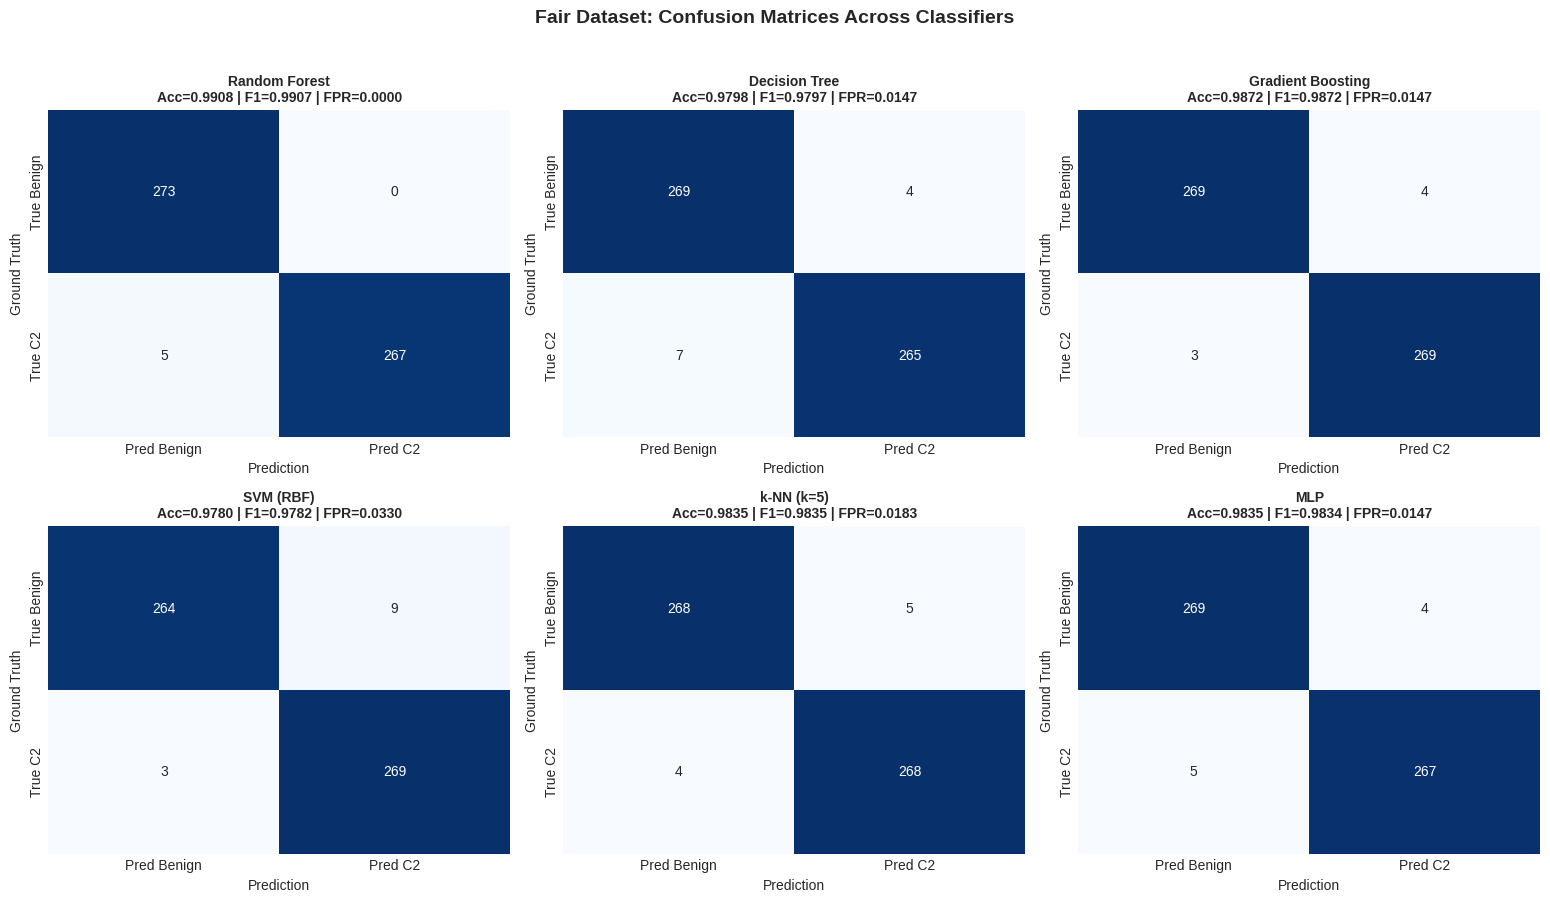

Saved: fair_all_classifiers_confusion_matrices.png


In [21]:
# Plot confusion matrices for all benchmark classifiers on the hold-out fair split
if 'classifiers_eval' not in globals():
    raise RuntimeError('Run Section 12.6 first to initialize classifiers_eval and split data.')

model_names = list(classifiers_eval.keys())
n_models = len(model_names)
n_cols = 3
n_rows = int(np.ceil(n_models / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5.2 * n_cols, 4.4 * n_rows))
axes = np.array(axes).reshape(-1)

for idx, name in enumerate(model_names):
    clf = classifiers_eval[name]
    X_tr = X_train_eval_scaled if name in ['SVM (RBF)', 'k-NN (k=5)', 'MLP'] else X_train_eval
    X_te = X_test_eval_scaled if name in ['SVM (RBF)', 'k-NN (k=5)', 'MLP'] else X_test_eval

    clf_copy = type(clf)(**clf.get_params())
    clf_copy.fit(X_tr, y_train_eval)
    y_pred = clf_copy.predict(X_te)

    cm = confusion_matrix(y_test_eval, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    acc = accuracy_score(y_test_eval, y_pred)
    f1 = f1_score(y_test_eval, y_pred, zero_division=0)
    fpr_val = fp / (fp + tn) if (fp + tn) > 0 else 0.0

    ax = axes[idx]
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
        xticklabels=['Pred Benign', 'Pred C2'],
        yticklabels=['True Benign', 'True C2']
    )
    ax.set_title(f"{name}\nAcc={acc:.4f} | F1={f1:.4f} | FPR={fpr_val:.4f}", fontsize=10, fontweight='bold')
    ax.set_xlabel('Prediction')
    ax.set_ylabel('Ground Truth')

for j in range(n_models, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Fair Dataset: Confusion Matrices Across Classifiers', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FAIR_EVAL_FIG_DIR, 'fair_all_classifiers_confusion_matrices.png'), dpi=200, bbox_inches='tight')
plt.show()

print('Saved: fair_all_classifiers_confusion_matrices.png')

## 12.8 Fair Dataset SHAP + Cross-Encryption Accuracy Comparison

This section adds the two missing figures for the new fair dataset workflow:
1. SHAP feature importance bar chart (Random Forest on fair dataset)
2. Cross-encryption accuracy comparison bar chart (full features vs timing-only)

/home/ioht22/contiki-ng/FYP/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


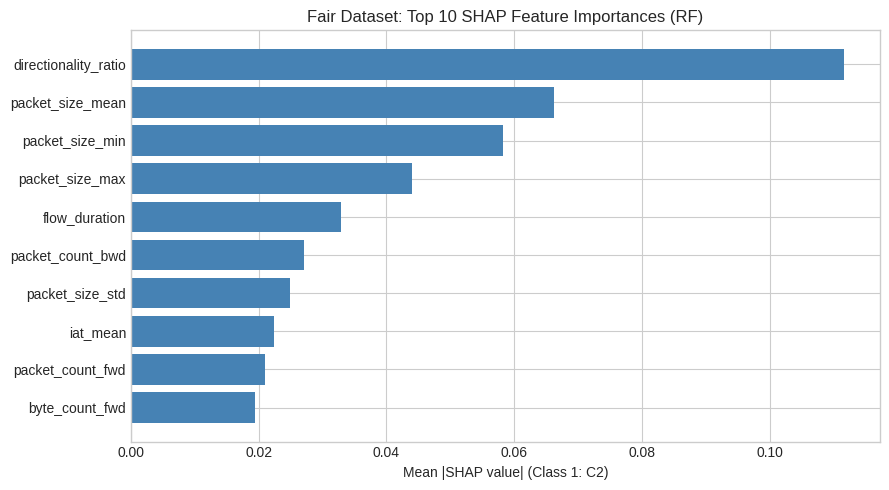

Saved SHAP CSV : /home/ioht22/contiki-ng/FYP/results/fair_dataset_evaluation/fair_shap_top20.csv
Saved SHAP plot: /home/ioht22/contiki-ng/FYP/results/fair_dataset_evaluation/fair_shap_feature_importance_bar.png


In [18]:
# 12.8.1 SHAP feature importance on fair dataset RF
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

# Reuse existing fair dataset variables; fallback to load if needed
if 'FAIR_EVAL_FIG_DIR' not in globals():
    FAIR_EVAL_FIG_DIR = '/home/ioht22/contiki-ng/FYP/results/fair_dataset_evaluation'
os.makedirs(FAIR_EVAL_FIG_DIR, exist_ok=True)

if 'FEATURES_EVAL' not in globals() or 'df_eval' not in globals():
    FAIR_DATASET_PATH = '/home/ioht22/contiki-ng/FYP/pcaps/finalcsv/fair_balanced_1362_dataset.csv'
    df_eval = pd.read_csv(FAIR_DATASET_PATH)
    if 'label_encoded' not in df_eval.columns:
        df_eval['label_encoded'] = df_eval['label'].apply(
            lambda x: 1 if str(x).strip().lower() in ['c&c', 'c2', 'malicious', '1', 'true', 'attack'] else 0
        )
    id_cols = ['label', 'label_encoded', 'src_ip', 'dst_ip', 'flow_id', 'timestamp', 'session_id']
    FEATURES_EVAL = [c for c in df_eval.columns if c not in id_cols and pd.api.types.is_numeric_dtype(df_eval[c])]

# Ensure we have a fitted RF model
if 'rf_model' not in globals() or not hasattr(rf_model, 'feature_importances_'):
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.model_selection import train_test_split
    X_tmp = df_eval[FEATURES_EVAL].fillna(0)
    y_tmp = df_eval['label_encoded'].astype(int).values
    X_tr_tmp, X_te_tmp, y_tr_tmp, y_te_tmp = train_test_split(
        X_tmp, y_tmp, test_size=0.3, random_state=42, stratify=y_tmp
    )
    rf_model = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
    rf_model.fit(X_tr_tmp, y_tr_tmp)

X_shap = df_eval[FEATURES_EVAL].fillna(0)

# Sample for runtime stability
sample_n = min(600, len(X_shap))
X_sample = X_shap.sample(n=sample_n, random_state=42)

explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_sample)

# Extract class-1 SHAP values robustly across SHAP versions
if isinstance(shap_values, list):
    sv = np.array(shap_values[1] if len(shap_values) > 1 else shap_values[0])
else:
    arr = np.array(shap_values)
    if arr.ndim == 3:
        sv = arr[:, :, 1] if arr.shape[2] > 1 else arr[:, :, 0]
    else:
        sv = arr

mean_abs_shap = np.abs(sv).mean(axis=0)
shap_df = pd.DataFrame({
    'feature': FEATURES_EVAL,
    'mean_abs_shap': mean_abs_shap
}).sort_values('mean_abs_shap', ascending=False)

shap_csv = os.path.join(FAIR_EVAL_FIG_DIR, 'fair_shap_top20.csv')
shap_df.head(20).to_csv(shap_csv, index=False)

plt.figure(figsize=(9, 5))
plot_df = shap_df.head(10).iloc[::-1]
plt.barh(plot_df['feature'], plot_df['mean_abs_shap'], color='steelblue')
plt.xlabel('Mean |SHAP value| (Class 1: C2)')
plt.title('Fair Dataset: Top 10 SHAP Feature Importances (RF)')
plt.tight_layout()
shap_png = os.path.join(FAIR_EVAL_FIG_DIR, 'fair_shap_feature_importance_bar.png')
plt.savefig(shap_png, dpi=200, bbox_inches='tight')
plt.show()

print('Saved SHAP CSV :', shap_csv)
print('Saved SHAP plot:', shap_png)

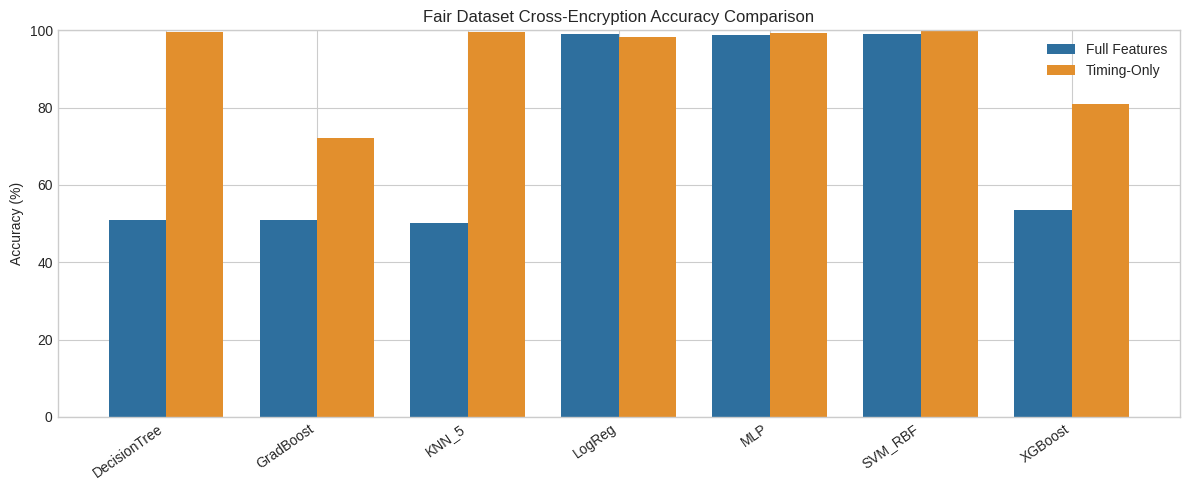

Saved comparison CSV : /home/ioht22/contiki-ng/FYP/results/fair_dataset_evaluation/fair_cross_encryption_accuracy_comparison.csv
Saved accuracy chart : /home/ioht22/contiki-ng/FYP/results/fair_dataset_evaluation/fair_cross_encryption_accuracy_comparison_bar.png

Preview:
       model  accuracy_full_features  accuracy_timing_only
DecisionTree                 50.9709               99.6157
   GradBoost                 50.9911               72.0672
       KNN_5                 50.1214               99.6157
      LogReg                 98.9280               98.1998
         MLP                 98.8875               99.3932
     SVM_RBF                 98.9482               99.7371
     XGBoost                 53.3981               81.0073


In [23]:
# 12.8.2 Cross-encryption accuracy comparison bar chart for fair dataset
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

if 'FAIR_EVAL_FIG_DIR' not in globals():
    FAIR_EVAL_FIG_DIR = '/home/ioht22/contiki-ng/FYP/results/fair_dataset_evaluation'
os.makedirs(FAIR_EVAL_FIG_DIR, exist_ok=True)

full_csv = '/home/ioht22/contiki-ng/FYP/results/fair_balanced_1362_non_rf_on_encrypted_balanced_test.csv'
timing_csv = '/home/ioht22/contiki-ng/FYP/results/fair_balanced_1362_non_rf_on_encrypted_balanced_test_timing9.csv'

full_df = pd.read_csv(full_csv)
timing_df = pd.read_csv(timing_csv)

# Keep only model + accuracy and align model names
# Note: these accuracy values are already percentages (e.g., 98.95), so do not multiply by 100.
full_acc = full_df[['model', 'accuracy']].copy().rename(columns={'accuracy': 'accuracy_full_features'})
timing_acc = timing_df[['model', 'accuracy']].copy().rename(columns={'accuracy': 'accuracy_timing_only'})

comp_df = pd.merge(full_acc, timing_acc, on='model', how='inner').sort_values('model').reset_index(drop=True)

# Save merged comparison table
comp_csv = os.path.join(FAIR_EVAL_FIG_DIR, 'fair_cross_encryption_accuracy_comparison.csv')
comp_df.to_csv(comp_csv, index=False)

# Plot grouped bar chart
x = np.arange(len(comp_df))
width = 0.38

plt.figure(figsize=(12, 5))
plt.bar(x - width/2, comp_df['accuracy_full_features'], width, label='Full Features', color='#2E6F9E')
plt.bar(x + width/2, comp_df['accuracy_timing_only'], width, label='Timing-Only', color='#E28F2D')
plt.xticks(x, comp_df['model'], rotation=35, ha='right')
plt.ylabel('Accuracy (%)')
plt.title('Fair Dataset Cross-Encryption Accuracy Comparison')
plt.ylim(0, 100)
plt.legend()
plt.tight_layout()

acc_png = os.path.join(FAIR_EVAL_FIG_DIR, 'fair_cross_encryption_accuracy_comparison_bar.png')
plt.savefig(acc_png, dpi=200, bbox_inches='tight')
plt.show()

print('Saved comparison CSV :', comp_csv)
print('Saved accuracy chart :', acc_png)
print('\nPreview:')
print(comp_df.to_string(index=False))

### Time-Only Model Feature Importances

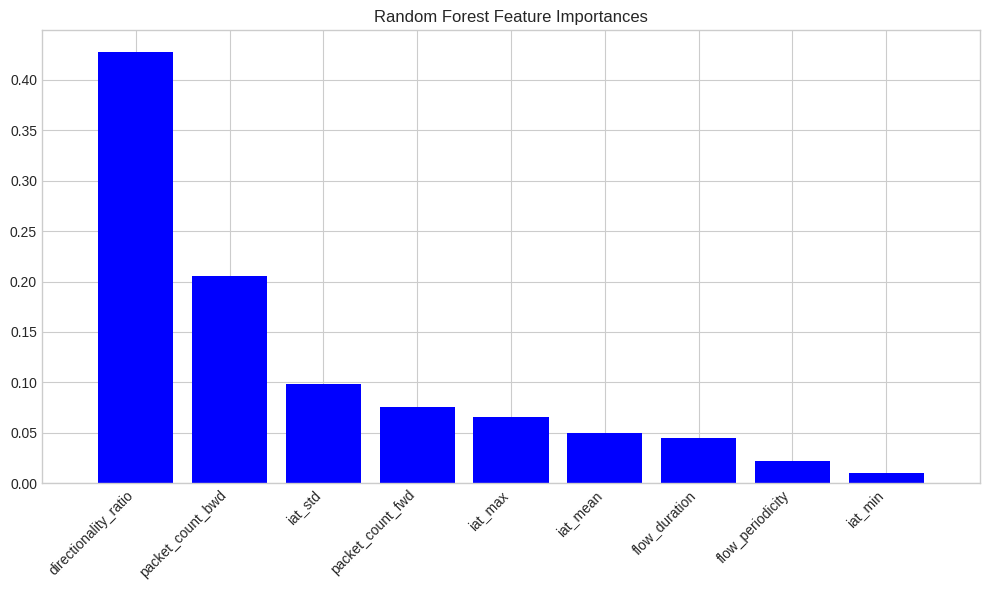

Top Behavioral Indicators Driving Botnet Detection (Timing-Only):
1. directionality_ratio (0.4278)
2. packet_count_bwd (0.2055)
3. iat_std (0.0984)
4. packet_count_fwd (0.0754)
5. iat_max (0.0659)
6. iat_mean (0.0501)
7. flow_duration (0.0450)
8. flow_periodicity (0.0216)
9. iat_min (0.0103)


In [23]:
# Feature Importance Analysis for Timing-Only Model
importances_timing = rf_timing.feature_importances_
indices_timing = np.argsort(importances_timing)[::-1]
feature_names_timing = [timing_features[i] for i in indices_timing]

plt.figure(figsize=(10, 6))
plt.title("Random Forest Feature Importances")
plt.bar(range(len(timing_features)), importances_timing[indices_timing], align="center", color='blue')
plt.xticks(range(len(timing_features)), feature_names_timing, rotation=45, ha='right')
plt.xlim([-1, len(timing_features)])
plt.tight_layout()
plt.show()

print("Top Behavioral Indicators Driving Botnet Detection (Timing-Only):")
for i in range(len(timing_features)):
    print(f"{i+1}. {feature_names_timing[i]} ({importances_timing[indices_timing[i]]:.4f})")


### Time-Only Model SHAP Feature Importances

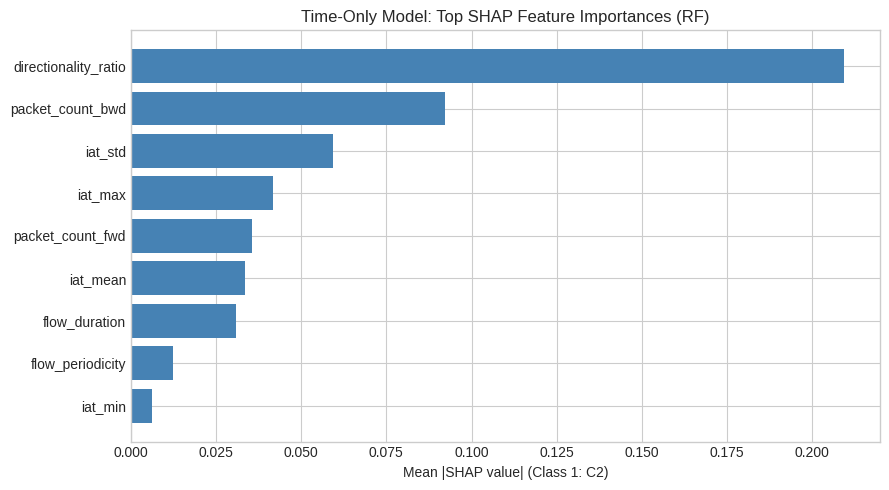

In [26]:
# SHAP Feature Importance Analysis for Timing-Only Model
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Ensure shap is installed
try:
    import shap
except ImportError:
    !pip install shap
    import shap

# Convert the numpy array to DataFrame to retain feature names
X_test_timing_df = pd.DataFrame(X_test_timing, columns=timing_features)

# Sample for runtime stability
sample_n = min(600, len(X_test_timing_df))
X_sample_timing = X_test_timing_df.sample(n=sample_n, random_state=42)

explainer_timing = shap.TreeExplainer(rf_timing)
shap_values_timing = explainer_timing.shap_values(X_sample_timing)

# Extract class-1 SHAP values robustly across SHAP versions
if isinstance(shap_values_timing, list):
    sv = np.array(shap_values_timing[1] if len(shap_values_timing) > 1 else shap_values_timing[0])
else:
    arr = np.array(shap_values_timing)
    if arr.ndim == 3:
        sv = arr[:, :, 1] if arr.shape[2] > 1 else arr[:, :, 0]
    else:
        sv = arr

mean_abs_shap = np.abs(sv).mean(axis=0)
shap_df = pd.DataFrame({
    'feature': timing_features,
    'mean_abs_shap': mean_abs_shap
}).sort_values('mean_abs_shap', ascending=False)

plt.figure(figsize=(9, 5))
plot_df = shap_df.head(10).iloc[::-1]
plt.barh(plot_df['feature'], plot_df['mean_abs_shap'], color='#4682b4')
plt.xlabel('Mean |SHAP value| (Class 1: C2)')
plt.title('Time-Only Model: Top SHAP Feature Importances (RF)')
plt.tight_layout()
plt.show()
